# setup

In [7]:
import datetime
import numpy as np
import pandas as pd
from yahoofinancials import YahooFinancials
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
# plt.style.use('fivethirtyeight')
%config InlineBackend.figure_format = 'retina'

In [8]:
sns.set_style("whitegrid")

plt.rcParams.update({
    'font.size'       : 9,
    'figure.figsize'  : (3.5, 2.8),
    'figure.dpi'      : 300,
    'savefig.dpi'     : 300,
    'text.usetex'     : True,
    'font.family'     : 'serif',
    'font.serif'      : ['Times New Roman'],
    'axes.labelsize'  : 9,
    'axes.titlesize'  : 9,
    'xtick.labelsize' : 8,
    'ytick.labelsize' : 8,
    'legend.fontsize' : 8,
    'lines.linewidth' : 1,
    'axes.linewidth'  : 1,
    'grid.linestyle'  : '--',
    'grid.linewidth'  : 0.5,
    'grid.alpha'      : 0.8,
})

sns.set_context(
    "paper", 
    rc={
        "font.size"      : 9,
        "axes.titlesize" : 9,
        "axes.labelsize" : 9, 
        'xtick.labelsize': 8,
        'ytick.labelsize': 8
    }
)

# data

## btc

In [2]:
ticker = 'BTC-USD'
start_date = datetime.datetime(2020, 1, 1).strftime('%Y-%m-%d')
end_date = datetime.datetime.now().strftime('%Y-%m-%d')

btc_yahoo_financials = YahooFinancials(ticker)

In [3]:
df = pd.DataFrame.from_dict(
    btc_yahoo_financials.get_historical_price_data(
        start_date,
        end_date,
        'daily'
    )[ticker]["prices"]
)
df["formatted_date"] = pd.to_datetime(df["formatted_date"])

In [4]:
df

,date,high,low,open,close,volume,adjclose,formatted_date
0,1577836800,7254.330566,7174.944336,7194.892090,7200.174316,18565664997,7200.174316,2020-01-01
1,1577923200,7212.155273,6935.270020,7202.551270,6985.470215,20802083465,6985.470215,2020-01-02
2,1578009600,7413.715332,6914.996094,6984.428711,7344.884277,28111481032,7344.884277,2020-01-03
3,1578096000,7427.385742,7309.514160,7345.375488,7410.656738,18444271275,7410.656738,2020-01-04
4,1578182400,7544.497070,7400.535645,7410.451660,7411.317383,19725074095,7411.317383,2020-01-05
...,...,...,...,...,...,...,...,...
1906,1742515200,84782.273438,83171.070312,84164.539062,84043.242188,19030452299,84043.242188,2025-03-21
1907,1742601600,84513.875000,83674.781250,84046.257812,83832.484375,9863214091,83832.484375,2025-03-22
1908,1742688000,86094.781250,83794.914062,83831.898438,86054.375000,12594615537,86054.375000,2025-03-23
1909,1742774400,88758.726562,85541.195312,86070.929688,87498.914062,34582604933,87498.914062,2025-03-24


<Axes: title={'center': 'BTC-USD Price'}, xlabel='formatted_date'>

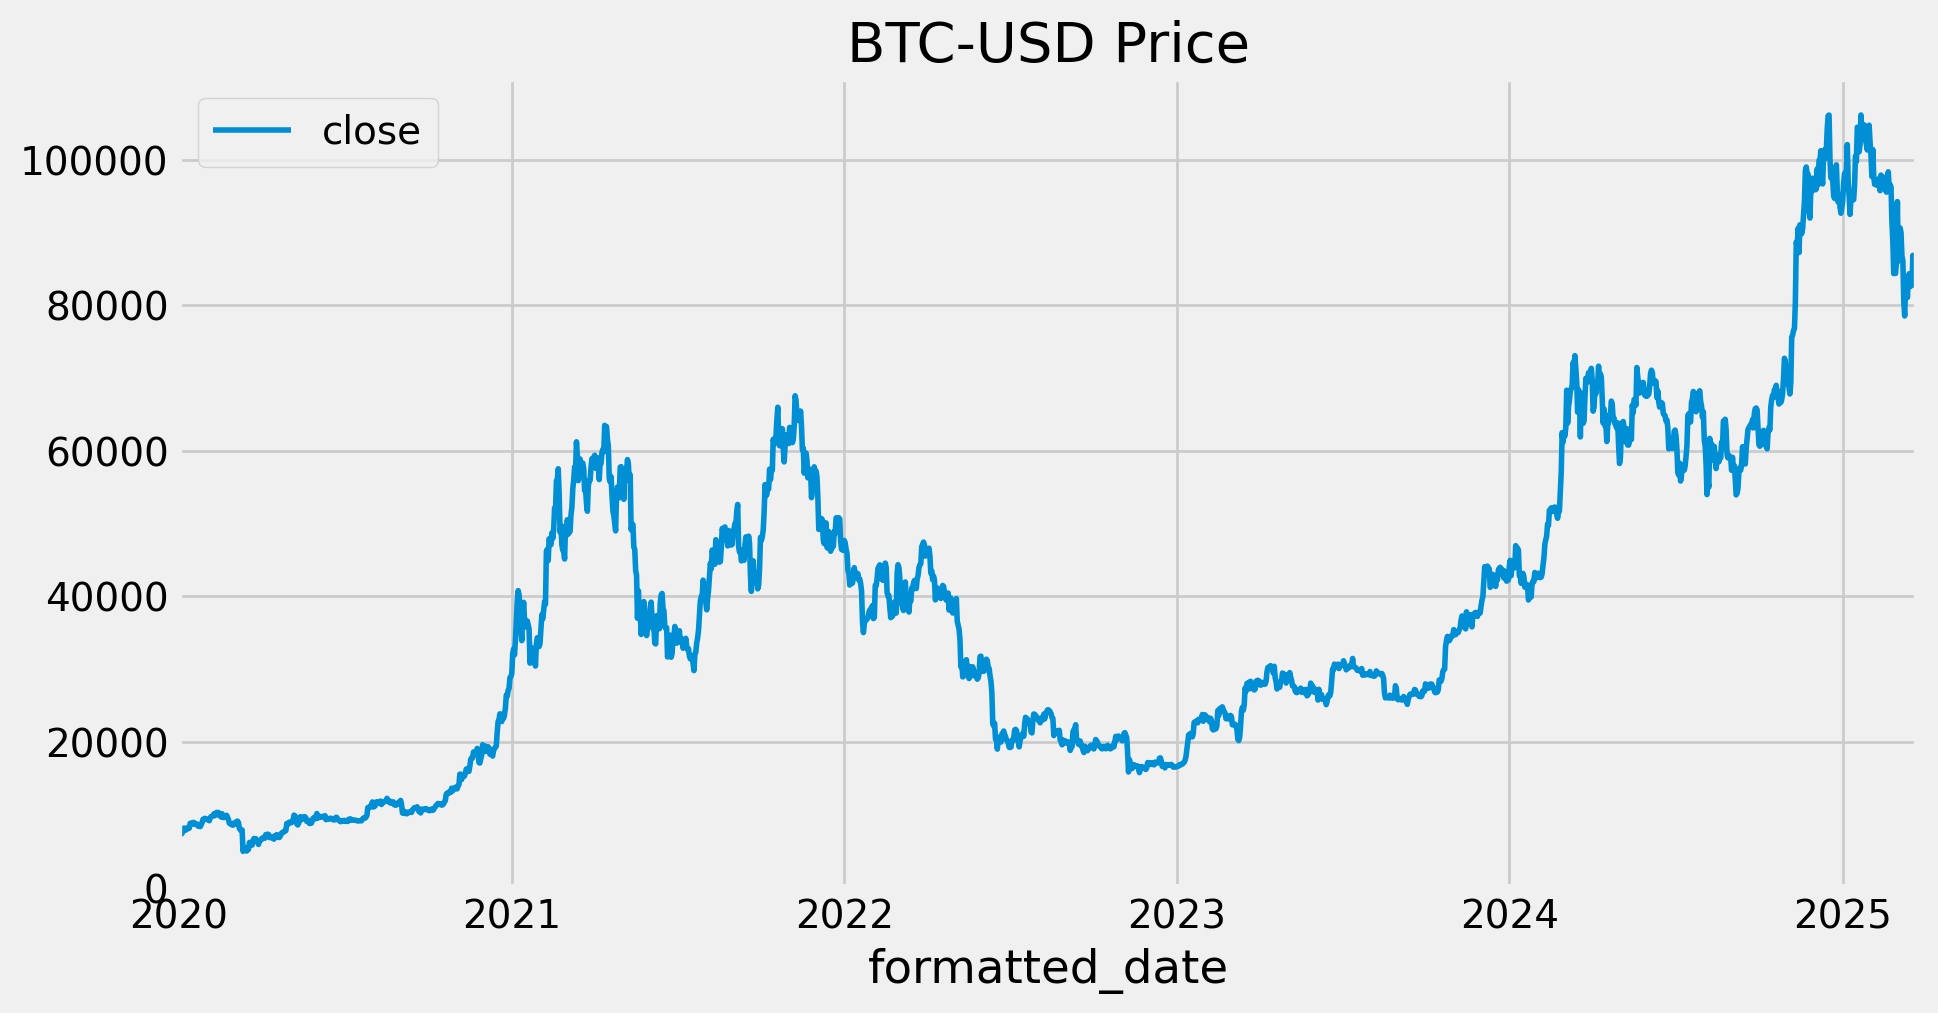

In [5]:
df.set_index("formatted_date").plot(y="close", title=f"{ticker} Price", figsize=(10, 5), linewidth=2)

In [6]:
df.to_parquet("../data/02_intermediate/historical_data_btc.parquet")

## u.s. fed funds target rate

[https://www.kaggle.com/datasets/aniketkolte04/u-s-fed-funds-target-rate](https://www.kaggle.com/datasets/aniketkolte04/u-s-fed-funds-target-rate)

In [21]:
df = pd.read_csv("../data/01_raw/us_fed_rate.csv")
# with pd.option_context("display.max_rows", None):
#     display(df)
df["Release Date"] = pd.to_datetime(df["Release Date"], format="%b %d, %Y")
df["Time"] = pd.to_datetime(df["Time"]).dt.hour
df

/tmp/ipykernel_2801177/973345299.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Time"] = pd.to_datetime(df["Time"]).dt.hour


,Release Date,Time,Actual,Forecast,Previous
0,2023-11-01,13,5.50%,5.50%,5.50%
1,2023-09-20,13,5.50%,5.50%,5.50%
2,2023-07-26,13,5.50%,5.50%,5.25%
3,2023-06-14,13,5.25%,5.25%,5.25%
4,2023-05-03,13,5.25%,5.25%,5.00%
...,...,...,...,...,...
196,1990-12-19,13,7.00%,-,7.25%
197,1990-12-07,13,7.25%,-,7.50%
198,1990-11-14,13,7.50%,-,7.75%
199,1990-10-29,13,7.75%,-,8.00%


In [22]:
cols = ['Actual', 'Forecast', 'Previous']
for c in cols:
    df[c] = np.where(
        df[c].astype(str).str.len() > 1,
        df[c].astype(str).str.replace("%", ""),
        "nan"
    )
df

,Release Date,Time,Actual,Forecast,Previous
0,2023-11-01,13,5.50,5.50,5.50
1,2023-09-20,13,5.50,5.50,5.50
2,2023-07-26,13,5.50,5.50,5.25
3,2023-06-14,13,5.25,5.25,5.25
4,2023-05-03,13,5.25,5.25,5.00
...,...,...,...,...,...
196,1990-12-19,13,7.00,nan,7.25
197,1990-12-07,13,7.25,nan,7.50
198,1990-11-14,13,7.50,nan,7.75
199,1990-10-29,13,7.75,nan,8.00


In [23]:
cols = ['Actual', 'Forecast', 'Previous']
for c in cols:
    df[c] = np.where(
        df[c].astype(str).str.len() > 1,
        df[c].astype(str).str.replace("%", "").astype(float) / 100,
        np.nan
    )
df

,Release Date,Time,Actual,Forecast,Previous
0,2023-11-01,13,0.0550,0.0550,0.0550
1,2023-09-20,13,0.0550,0.0550,0.0550
2,2023-07-26,13,0.0550,0.0550,0.0525
3,2023-06-14,13,0.0525,0.0525,0.0525
4,2023-05-03,13,0.0525,0.0525,0.0500
...,...,...,...,...,...
196,1990-12-19,13,0.0700,NaN,0.0725
197,1990-12-07,13,0.0725,NaN,0.0750
198,1990-11-14,13,0.0750,NaN,0.0775
199,1990-10-29,13,0.0775,NaN,0.0800


In [24]:
df.to_parquet("../data/02_intermediate/us_fed_rate.parquet")

## dow jones & s&p500 indices

In [31]:
df = pd.read_csv("../data/01_raw/DJCA.csv")
df["observation_date"] = pd.to_datetime(df["observation_date"])
df.to_parquet("../data/02_intermediate/DJCA.parquet")
df 

,observation_date,DJCA
0,2015-03-25,6305.24
1,2015-03-26,6277.94
2,2015-03-27,6295.78
3,2015-03-30,6378.85
4,2015-03-31,6328.12
...,...,...
2604,2025-03-18,12999.20
2605,2025-03-19,13092.76
2606,2025-03-20,13086.19
2607,2025-03-21,13072.14


In [33]:
df = pd.read_csv("../data/01_raw/DJIA.csv")
df["observation_date"] = pd.to_datetime(df["observation_date"])
df.to_parquet("../data/02_intermediate/DJIA.parquet")
df 

,observation_date,DJIA
0,2015-03-25,17718.54
1,2015-03-26,17678.23
2,2015-03-27,17712.66
3,2015-03-30,17976.31
4,2015-03-31,17776.12
...,...,...
2604,2025-03-18,41581.31
2605,2025-03-19,41964.63
2606,2025-03-20,41953.32
2607,2025-03-21,41985.35


In [34]:
df = pd.read_csv("../data/01_raw/DJTA.csv")
df["observation_date"] = pd.to_datetime(df["observation_date"])
df.to_parquet("../data/02_intermediate/DJTA.parquet")
df 

,observation_date,DJTA
0,2015-03-25,8727.40
1,2015-03-26,8677.84
2,2015-03-27,8700.34
3,2015-03-30,8788.06
4,2015-03-31,8741.41
...,...,...
2604,2025-03-18,14619.60
2605,2025-03-19,14691.92
2606,2025-03-20,14637.85
2607,2025-03-21,14608.59


In [35]:
df = pd.read_csv("../data/01_raw/DJUA.csv")
df["observation_date"] = pd.to_datetime(df["observation_date"])
df.to_parquet("../data/02_intermediate/DJUA.parquet")
df 

,observation_date,DJUA
0,2015-03-25,581.99
1,2015-03-26,576.79
2,2015-03-27,580.51
3,2015-03-30,588.14
4,2015-03-31,587.08
...,...,...
2604,2025-03-18,1013.50
2605,2025-03-19,1014.27
2606,2025-03-20,1018.01
2607,2025-03-21,1008.99


In [36]:
df = pd.read_csv("../data/01_raw/SP500.csv")
df["observation_date"] = pd.to_datetime(df["observation_date"])
df.to_parquet("../data/02_intermediate/SP500.parquet")
df 

,observation_date,SP500
0,2015-03-25,2061.05
1,2015-03-26,2056.15
2,2015-03-27,2061.02
3,2015-03-30,2086.24
4,2015-03-31,2067.89
...,...,...
2604,2025-03-18,5614.66
2605,2025-03-19,5675.29
2606,2025-03-20,5662.89
2607,2025-03-21,5667.56


## crypto fear & greed index

In [43]:
df = pd.read_csv("../data/01_raw/CryptoGreedFear.csv")
df["date"] = pd.to_datetime(df["date"])
df.to_parquet("../data/02_intermediate/greed_and_fear.parquet")
df

,date,fng_value,fng_classification
0,2024-10-03,37,Fear
1,2024-10-02,42,Fear
2,2024-10-01,50,Neutral
3,2024-09-30,61,Greed
4,2024-09-29,63,Greed
...,...,...,...
2429,2018-02-05,11,Extreme Fear
2430,2018-02-04,24,Extreme Fear
2431,2018-02-03,40,Fear
2432,2018-02-02,15,Extreme Fear


# plots

,high,low,open,close,volume,adjclose,formatted_date
date,,,,,,,
2020-01-01,7254.330566,7174.944336,7194.892090,7200.174316,18565664997,7200.174316,2020-01-01
2020-01-02,7212.155273,6935.270020,7202.551270,6985.470215,20802083465,6985.470215,2020-01-02
2020-01-03,7413.715332,6914.996094,6984.428711,7344.884277,28111481032,7344.884277,2020-01-03
2020-01-04,7427.385742,7309.514160,7345.375488,7410.656738,18444271275,7410.656738,2020-01-04
2020-01-05,7544.497070,7400.535645,7410.451660,7411.317383,19725074095,7411.317383,2020-01-05


,observation_date,DJCA
date,,
2015-03-25,2015-03-25,6305.24
2015-03-26,2015-03-26,6277.94
2015-03-27,2015-03-27,6295.78
2015-03-30,2015-03-30,6378.85
2015-03-31,2015-03-31,6328.12


,observation_date,DJIA
date,,
2015-03-25,2015-03-25,17718.54
2015-03-26,2015-03-26,17678.23
2015-03-27,2015-03-27,17712.66
2015-03-30,2015-03-30,17976.31
2015-03-31,2015-03-31,17776.12


,fng_value,fng_classification
date,,
2024-10-03,37,Fear
2024-10-02,42,Fear
2024-10-01,50,Neutral
2024-09-30,61,Greed
2024-09-29,63,Greed


,observation_date,SP500
date,,
2015-03-25,2015-03-25,2061.05
2015-03-26,2015-03-26,2056.15
2015-03-27,2015-03-27,2061.02
2015-03-30,2015-03-30,2086.24
2015-03-31,2015-03-31,2067.89


,Release Date,Time,Actual,Forecast,Previous
date,,,,,
2023-11-01,2023-11-01,13,0.0550,0.0550,0.0550
2023-09-20,2023-09-20,13,0.0550,0.0550,0.0550
2023-07-26,2023-07-26,13,0.0550,0.0550,0.0525
2023-06-14,2023-06-14,13,0.0525,0.0525,0.0525
2023-05-03,2023-05-03,13,0.0525,0.0525,0.0500


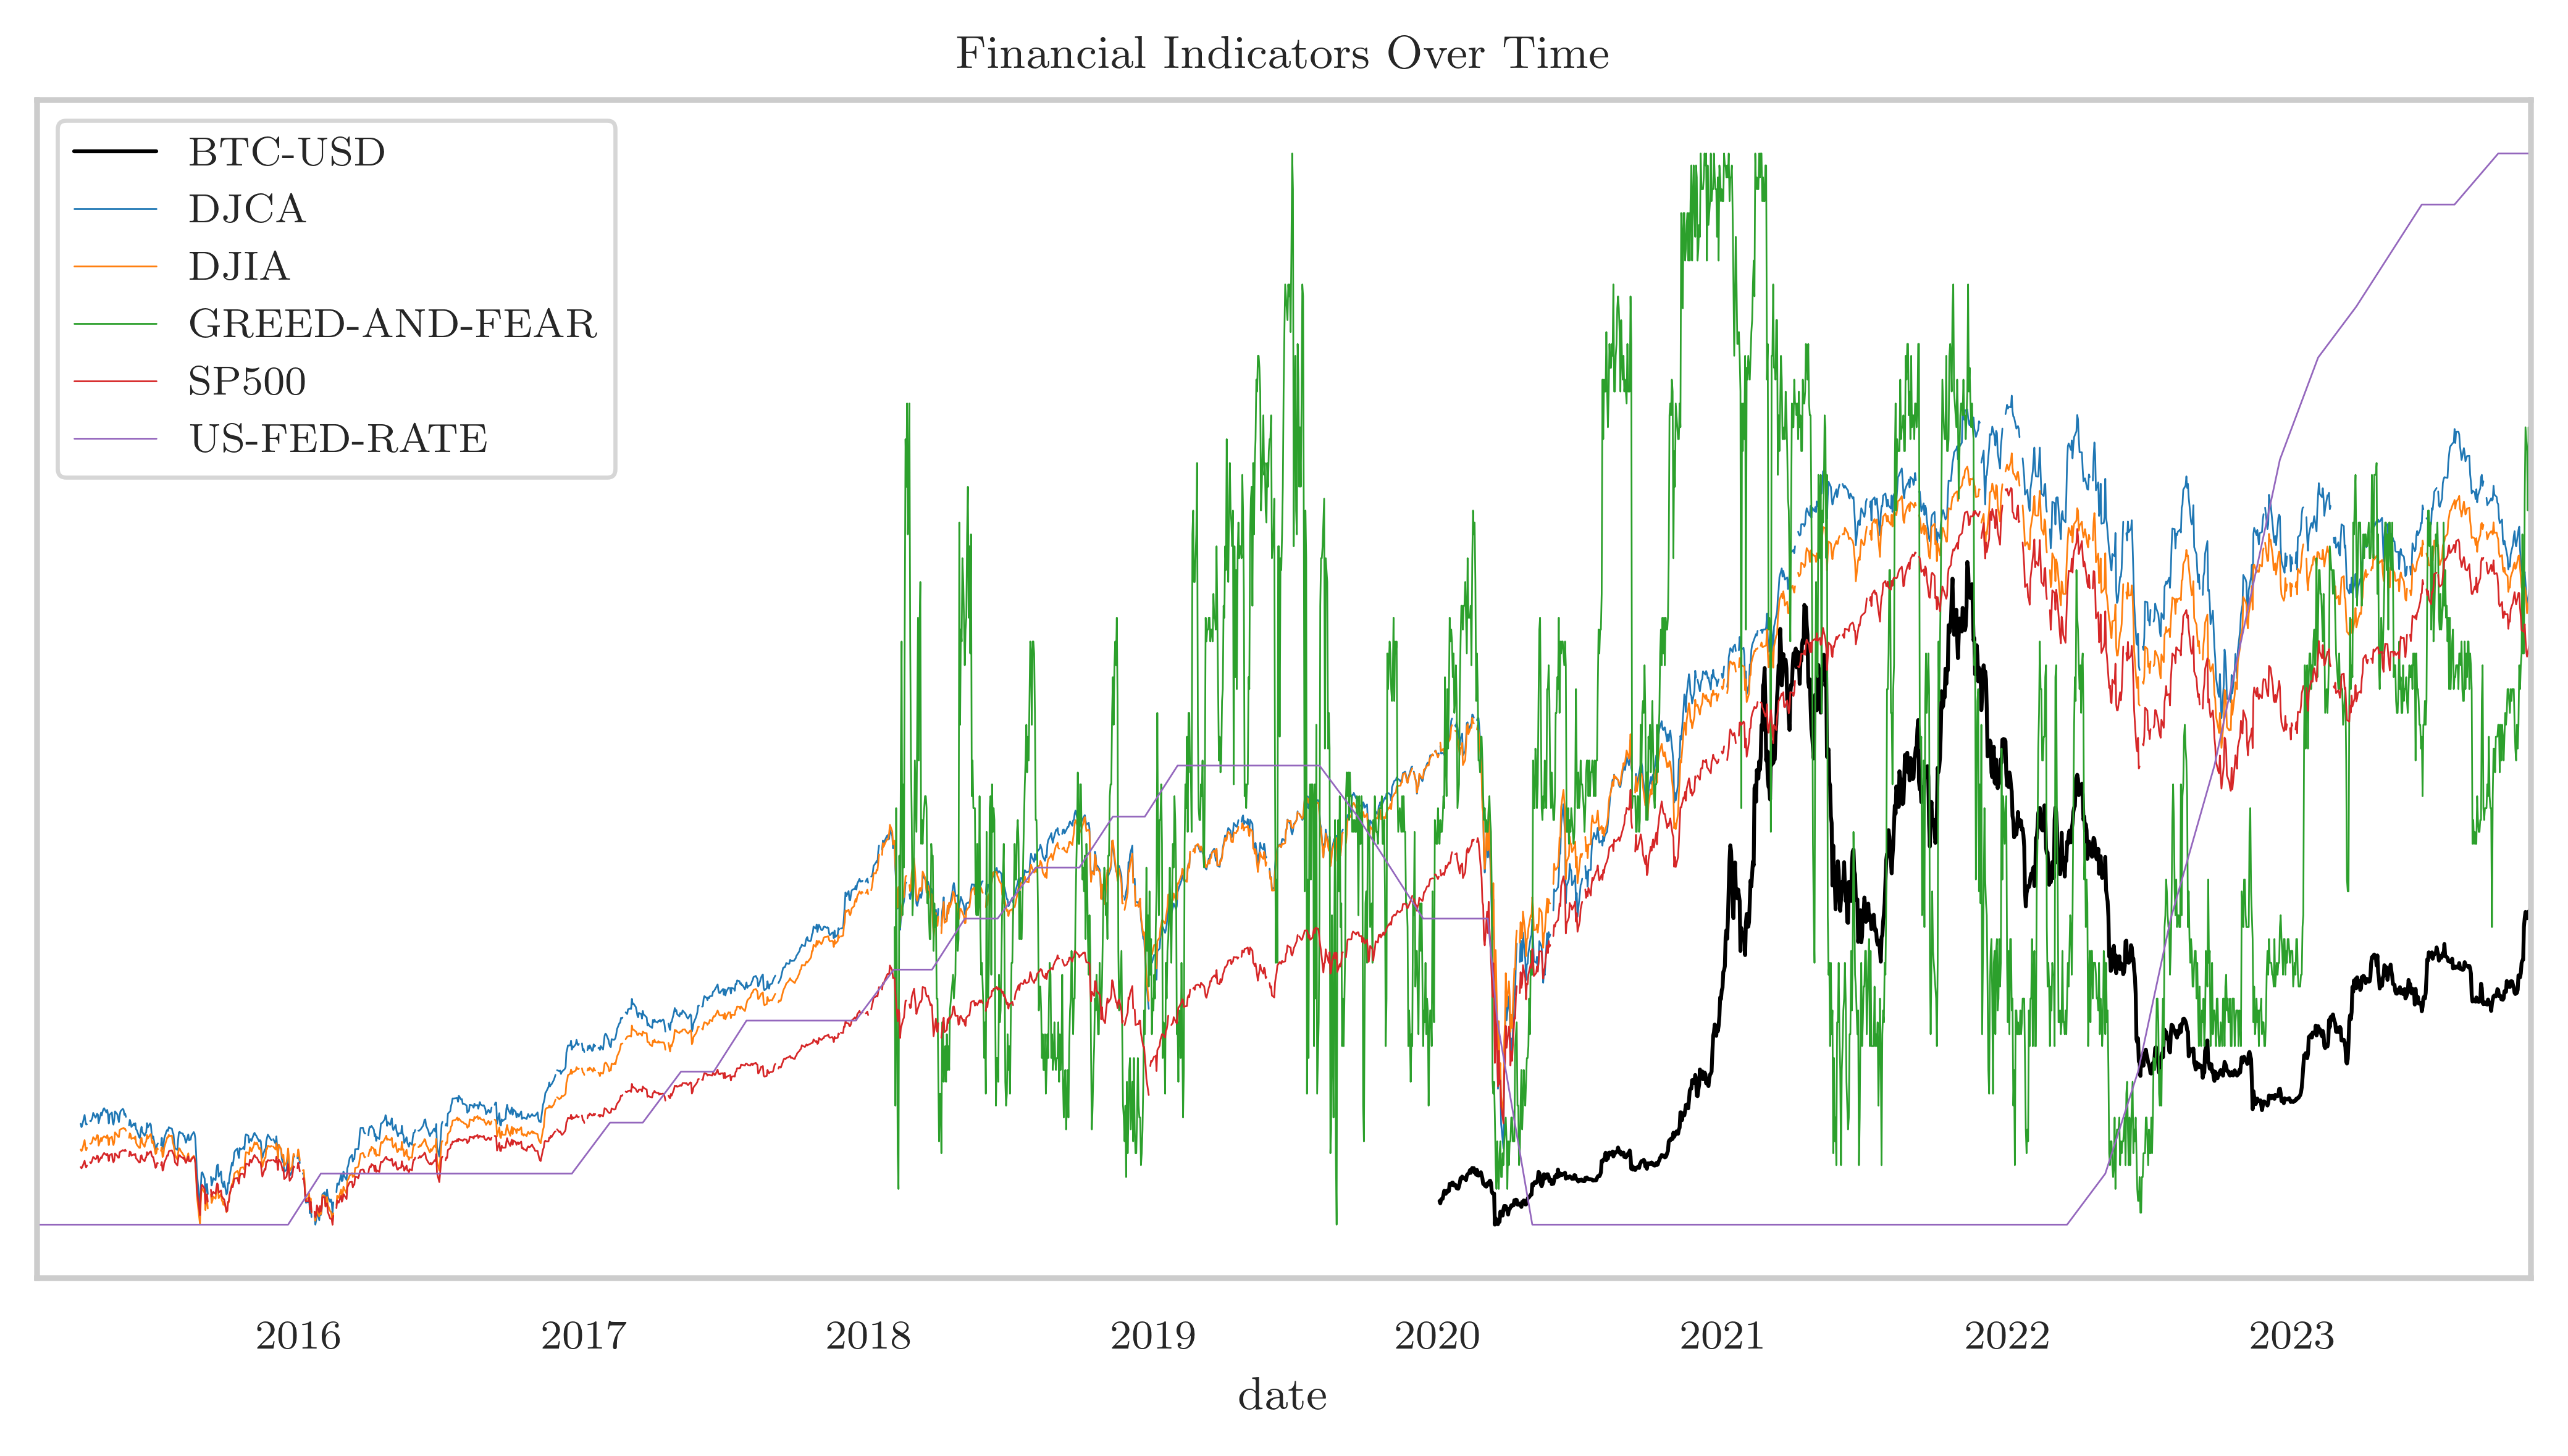

In [50]:
data_dir = Path("../data/02_intermediate")
#
btc = pd.read_parquet(data_dir / "historical_data_btc.parquet")
fed = pd.read_parquet(data_dir / "us_fed_rate.parquet")
sp500 = pd.read_parquet(data_dir / "SP500.parquet")
fng = pd.read_parquet(data_dir / "greed_and_fear.parquet")
djia = pd.read_parquet(data_dir / "DJIA.parquet")
djca = pd.read_parquet(data_dir / "DJCA.parquet")
#
btc['date'] = pd.to_datetime(btc['formatted_date'])
fed['date'] = pd.to_datetime(fed['Release Date'])
sp500['date'] = pd.to_datetime(sp500['observation_date'])
fng['date'] = pd.to_datetime(fng['date'])
djia['date'] = pd.to_datetime(djia['observation_date'])
djca['date'] = pd.to_datetime(djca['observation_date'])
#
data = {
    'btc-usd': btc.copy(),
    'us-fed-rate': fed.copy(),
    'sp500': sp500.copy(),
    'greed-and-fear': fng.copy(),
    'djia': djia.copy(),
    'djca': djca.copy()
}

# iterate through the keys in sorted order and plot all lines ignoring the scale differences
_, ax = plt.subplots(figsize=(7, 4))
ax1 = ax.twinx()
ax2 = ax.twinx()
ax3 = ax.twinx()
ax4 = ax.twinx()
ax5 = ax.twinx()

for k in sorted(data.keys()):
    df = data[k]
    df = df.set_index('date')
    display(df.head())
    if 'close' in df.columns:
        value = 'close'
        df.plot(
            y=value, 
            ax=ax,
            label=k.upper(), 
            linewidth=0.75,
            color='k'
        )
        ax.grid(False)
        ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False, labelright=False)
        ax.get_legend().remove()
    elif 'DJCA' in df.columns:
        value = 'DJCA'
        df.plot(
            y=value, 
            ax=ax1,
            label=k.upper(), 
            linewidth=0.33,
            color='tab:blue'
        )
        ax1.grid(False)
        ax1.tick_params(axis='y', which='both', left=False, right=False, labelleft=False, labelright=False)
        ax1.get_legend().remove()
    elif 'DJIA' in df.columns:
        value = 'DJIA'
        df.plot(
            y=value, 
            ax=ax2,
            label=k.upper(), 
            linewidth=0.33,
            color='tab:orange'
        )
        ax2.grid(False)
        ax2.tick_params(axis='y', which='both', left=False, right=False, labelleft=False, labelright=False)
        ax2.get_legend().remove()
    elif 'fng_value' in df.columns:
        value = 'fng_value'
        df.plot(
            y=value, 
            ax=ax3,
            label=k.upper(), 
            linewidth=0.33,
            color='tab:green'
        )
        ax3.grid(False)
        ax3.tick_params(axis='y', which='both', left=False, right=False, labelleft=False, labelright=False)
        ax3.get_legend().remove()
    elif 'SP500' in df.columns:
        value = 'SP500'
        df.plot(
            y=value, 
            ax=ax4,
            label=k.upper(), 
            linewidth=0.33,
            color='tab:red'
        )
        ax4.grid(False)
        ax4.tick_params(axis='y', which='both', left=False, right=False, labelleft=False, labelright=False)
        ax4.get_legend().remove()
    elif 'Previous' in df.columns:
        value = 'Previous'
        df.loc[
            df.index >= '2015-01-01', 
        ].plot(
            y=value, 
            ax=ax5,
            label=k.upper(), 
            linewidth=0.33,
            color='tab:purple'
        )
        ax5.grid(False)
        ax5.tick_params(axis='y', which='both', left=False, right=False, labelleft=False, labelright=False)
        ax5.get_legend().remove()


lines, labels = ax.get_legend_handles_labels()
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
lines5, labels5 = ax5.get_legend_handles_labels()

ax.legend(
    lines + lines1 + lines2 + lines3 + lines4 + lines5,
    labels + labels1 + labels2 + labels3 + labels4 + labels5,
    loc='upper left',
    fontsize=8
)
ax.set_title("Financial Indicators Over Time")

plt.tight_layout()

plt.savefig("../data/plots/financial_indicators_over_time.png", dpi=300, bbox_inches='tight')

.